In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [5]:
from huggingface_hub import hf_hub_download
dataset = load_dataset("madilcy/arabic-medical-qa-MERGED-MAQA-MMMLU-MI")
df = pd.DataFrame(dataset['train'])
df.head()

Found cached dataset json (C:/Users/Lenovo/.cache/huggingface/datasets/madilcy___json/madilcy--arabic-medical-qa-MERGED-MAQA-MMMLU-MI-578fc643e7e02031/0.0.0/e347ab1c932092252e717ff3f949105a4dd28b27e842dd53157d2f72e276c2e4)


  0%|          | 0/1 [00:00<?, ?it/s]

,q_body,a_body,category,q_body_count,a_body_count,question,reply
0,None,None,جراحة عامة,NaN,NaN,\nالسلام عليكم . يوجد لسع والم وتحجر وورم فى ث...,راجع جراحك ولا خوف\n0\n عامة
1,انا عندي البروتينات ع الرئه من زمان اوي وعندي ...,السؤال غير واضح,امراض الجهاز التنفسي,36.0,3.0,None,None
2,None,None,امراض القلب و الشرايين,NaN,NaN,\nاعاني من صداع دائم و نزيف في الانف ، يصاحبه ...,نعم ممكن، لكن في هذا العمر ينبغي استبعاد أسباب...
3,None,None,امراض باطنية,NaN,NaN,\nعمر 54 الضغط طبيعي وزني 74 طولي 162 مصاب بال...,مين قالك تاخذ B12 ما هي بالمزاج ولا بالكيف يوق...
4,None,None,امراض الجهاز التنفسي,NaN,NaN,\nكان عندى حساسية صدر والتهاب رءوى شديد وشفيت ...,تمام المفروض لاناخذ المضادات الحيوية من نفسنا ...


In [33]:
print("SCHEMA OVERVIEW")
print(df.dtypes)
print()
df.info()
print(f"Columns    : {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
duplicates = df.duplicated().sum()

SCHEMA OVERVIEW
q_body                  object
a_body                  object
category                object
q_body_count           float64
a_body_count           float64
question                object
reply                   object
question_word_count      int64
answer_word_count        int64
dtype: object

<class 'pandas.core.frame.DataFrame'>
Index: 38873 entries, 0 to 86472
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   q_body               0 non-null      object 
 1   a_body               0 non-null      object 
 2   category             38873 non-null  object 
 3   q_body_count         0 non-null      float64
 4   a_body_count         0 non-null      float64
 5   question             38873 non-null  object 
 6   reply                38873 non-null  object 
 7   question_word_count  38873 non-null  int64  
 8   answer_word_count    38873 non-null  int64  
dtypes: float64(2), int64(2), object(

In [17]:
df = df.dropna(subset=['reply'])

print(f"Rows after cleaning : {df.shape[0]}")
print(f"Dropped             : 101 rows")
print(f"Duplicates          : {duplicates} rows")

Rows after cleaning : 38873
Dropped             : 101 rows
Duplicates          : 16043 rows


In [21]:
col_q = df.columns[0]
col_a = df.columns[1]
df['question_word_count'] = df[col_q].apply(lambda x: len(str(x).split()))
df['answer_word_count'] = df[col_a].apply(lambda x: len(str(x).split()))

print("\n Word Count Statistics ")
display(df[['question_word_count', 'answer_word_count']].describe())


 Word Count Statistics 


,question_word_count,answer_word_count
count,38873.0,38873.0
mean,1.0,1.0
std,0.0,0.0
min,1.0,1.0
25%,1.0,1.0
50%,1.0,1.0
75%,1.0,1.0
max,1.0,1.0


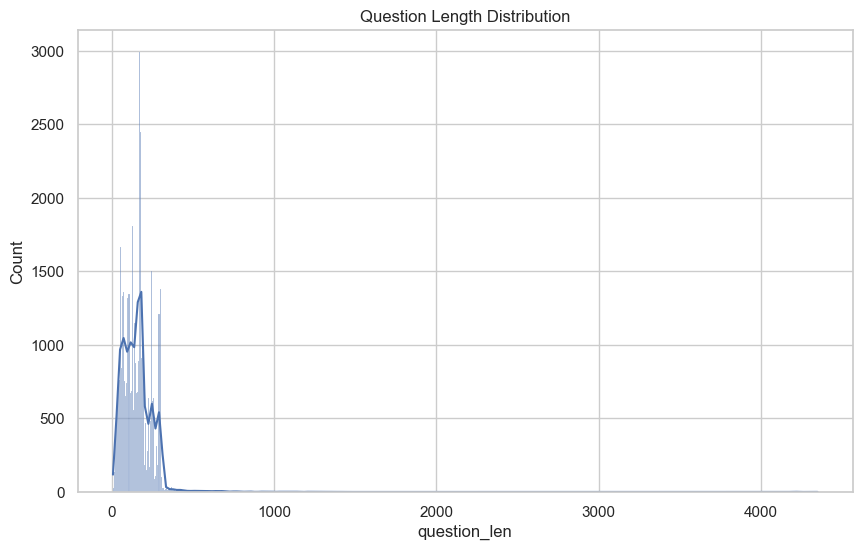

In [34]:
df['question_len'] = df['question'].astype(str).apply(len)

plt.figure()
sns.histplot(df['question_len'], kde=True)
plt.title("Question Length Distribution")
plt.show()


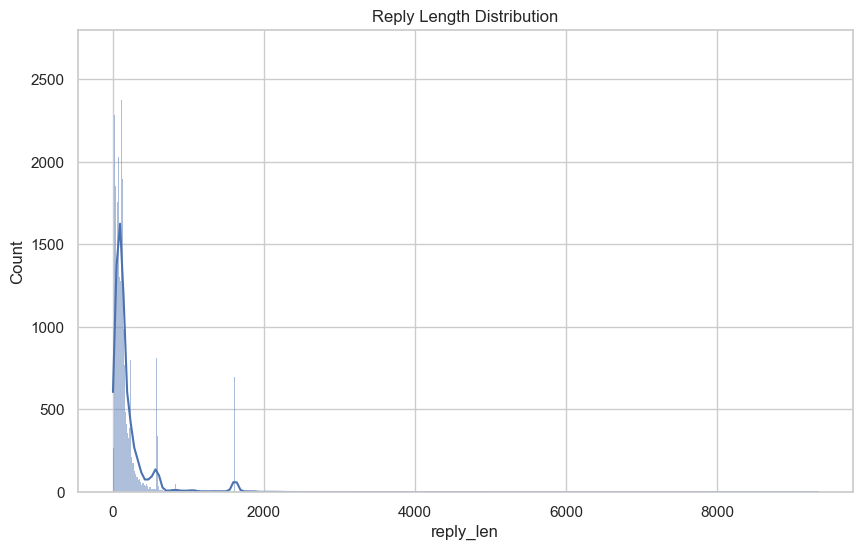

In [35]:
df['reply_len'] = df['reply'].astype(str).apply(len)

plt.figure()
sns.histplot(df['reply_len'], kde=True)
plt.title("Reply Length Distribution")
plt.show()

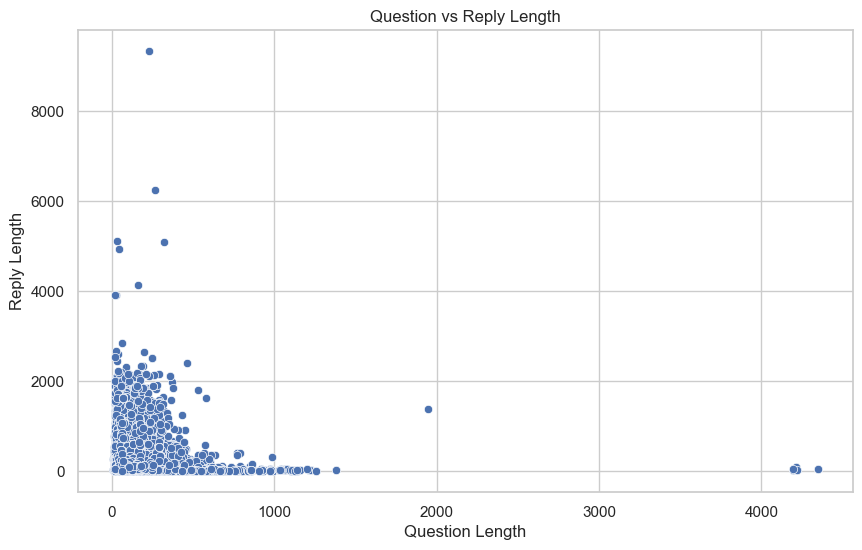

In [36]:
plt.figure()
sns.scatterplot(x=df['question_len'], y=df['reply_len'])
plt.title("Question vs Reply Length")
plt.xlabel("Question Length")
plt.ylabel("Reply Length")
plt.show()

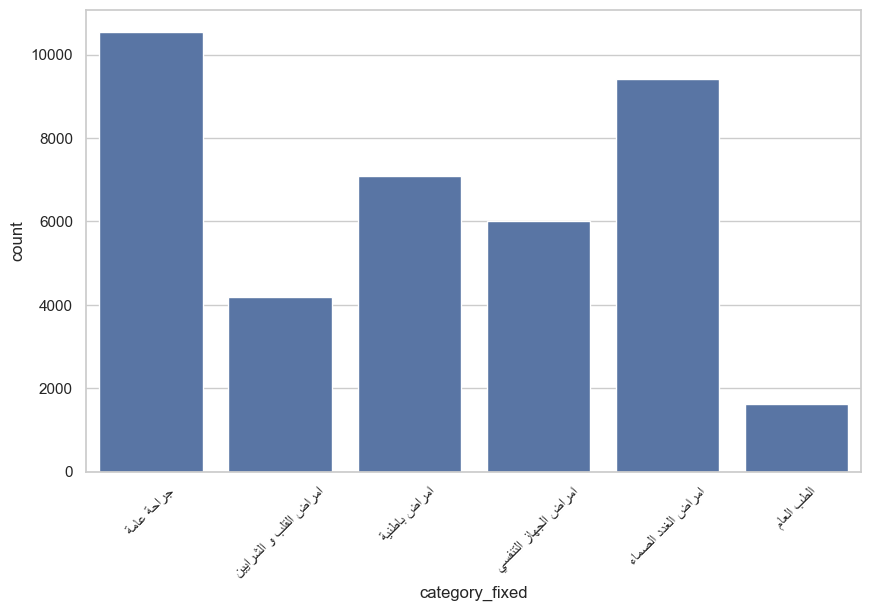

In [46]:
def fix_arabic(text):
    reshaped = arabic_reshaper.reshape(str(text))
    bidi_text = get_display(reshaped)
    return bidi_text
df['category_fixed'] = df['category'].apply(fix_arabic)

sns.countplot(x='category_fixed', data=df)
plt.xticks(rotation=45)
plt.show()

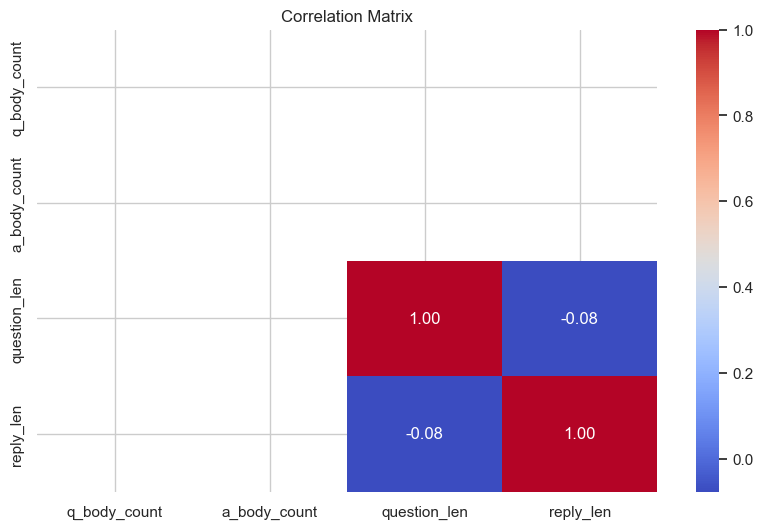

In [39]:
corr = df[['q_body_count', 'a_body_count', 'question_len', 'reply_len']].corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [40]:
print(df[['q_body_count','a_body_count']].describe())
print(df[['q_body_count','a_body_count']].isnull().sum())

       q_body_count  a_body_count
count           0.0           0.0
mean            NaN           NaN
std             NaN           NaN
min             NaN           NaN
25%             NaN           NaN
50%             NaN           NaN
75%             NaN           NaN
max             NaN           NaN
q_body_count    38873
a_body_count    38873
dtype: int64


In [41]:
df = df.drop(columns=['q_body_count', 'a_body_count'])

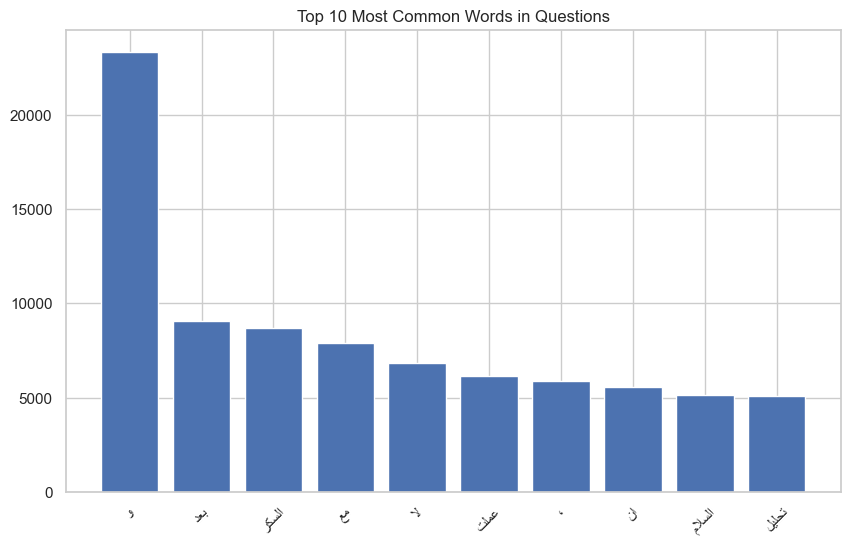

In [48]:
def fix_arabic(text):
    reshaped = arabic_reshaper.reshape(str(text))
    bidi_text = get_display(reshaped)
    return bidi_text
words_fixed = [fix_arabic(w) for w in words]

plt.figure()
plt.bar(words_fixed, counts)
plt.title(fix_arabic("Top 10 Most Common Words in Questions"))
plt.xticks(rotation=45)
plt.show()

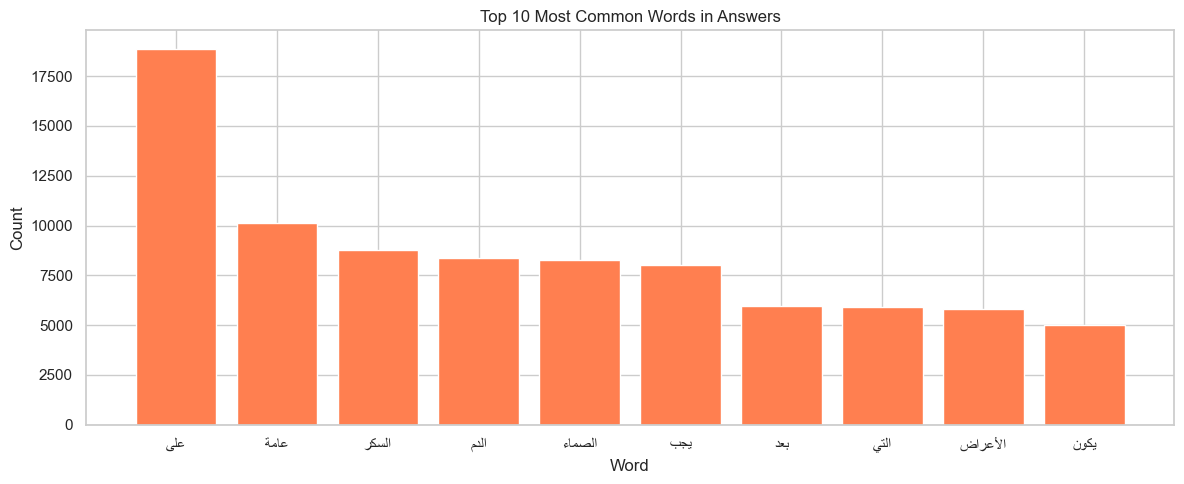

In [29]:
all_words_ans = ' '.join(df['reply']).split()
all_words_ans = [w for w in all_words_ans if len(w) > 2]

top_words_ans = Counter(all_words_ans).most_common(10)
words_ans, counts_ans = zip(*top_words_ans)

visual_words_ans = [process_arabic_text_for_visuals(w) for w in words_ans]

plt.figure(figsize=(12, 5))
plt.bar(visual_words_ans, counts_ans, color='coral') 

plt.title('Top 10 Most Common Words in Answers')
plt.xlabel('Word')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/top_answer_words.png', dpi=150)
plt.show()